# Air Quality Analysis: Los Angeles vs Vancouver
## Before, During, and After the 2025 LA Wildfires

### Research Question
How did the January 2025 Los Angeles wildfires impact air quality
(PM2.5, CO, and O3) compared to Vancouver, a city unaffected by
wildfires, across the pre-fire (December 2024), during-fire
(January 2025), and post-fire (February 2025) periods?

### Introduction
In January 2025, Los Angeles experienced devastating wildfires that
severely impacted the region's air quality. This notebook compares
air quality data from two cities:

- Los Angeles (USA): Directly affected by the January 2025 wildfires
- Vancouver (Canada): A nearby city unaffected by the wildfires,
  serving as a control city for comparison

Three key pollutants are analyzed:
- PM2.5: Fine particulate matter, the primary pollutant produced
  by wildfire smoke
- CO: Carbon monoxide, produced by incomplete combustion during fires
- O3: Ground-level ozone, formed when wildfire smoke reacts with sunlight

The analysis covers three periods:
- Pre-fire: December 2024
- During fire: January 2025
- Post-fire: February 2025

In [1]:
# Install and import required libraries
!pip install requests pandas matplotlib --quiet

import requests
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


**Data Retrieval from OpenAQ**

In [2]:
# API Key and Settings
API_KEY = "21768064a7f18b65ed11b88306cae02ca4de1c65c4486d121a1c5204b7991212"

# Sensor IDs for each city and parameter
sensors = {
    "Los Angeles": {
        "PM2.5": 25196,
        "CO": 23019,
        "O3": 25193
    },
    "Vancouver": {
        "PM2.5": 22030,
        "CO": 1714554,
        "O3": 2691
    }
}

# Time periods
periods = {
    "Pre-Fire (Dec 2024)": ("2024-12-01", "2024-12-31"),
    "During Fire (Jan 2025)": ("2025-01-01", "2025-01-31"),
    "Post-Fire (Feb 2025)": ("2025-02-01", "2025-02-28")
}

print("Settings loaded!")
print(f"Cities: {list(sensors.keys())}")
print(f"Parameters: {list(sensors['Los Angeles'].keys())}")
print(f"Periods: {list(periods.keys())}")

Settings loaded!
Cities: ['Los Angeles', 'Vancouver']
Parameters: ['PM2.5', 'CO', 'O3']
Periods: ['Pre-Fire (Dec 2024)', 'During Fire (Jan 2025)', 'Post-Fire (Feb 2025)']


In [3]:
# Fetch daily air quality data for all cities, parameters and periods
print("Fetching data...\n")
all_data = []

for city, params_dict in sensors.items():
    print(f"--- {city} ---")
    for param_name, sensor_id in params_dict.items():
        for period_name, (date_from, date_to) in periods.items():
            url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements/daily"
            headers = {"X-API-Key": API_KEY}
            params = {
                "datetime_from": date_from,
                "datetime_to": date_to,
                "limit": 100
            }
            response = requests.get(url, headers=headers, params=params)
            data = response.json()

            if "results" not in data or len(data["results"]) == 0:
                print(f"  No data for {param_name} | {period_name}")
                continue

            records = []
            for r in data["results"]:
                records.append({
                    "date": r["period"]["datetimeFrom"]["utc"][:10],
                    "city": city,
                    "parameter": param_name,
                    "period": period_name,
                    "value": r["value"]
                })

            df = pd.DataFrame(records)
            print(f"  {param_name} | {period_name}: {len(df)} records")
            all_data.append(df)

# Combine into one dataframe
df_all = pd.concat(all_data, ignore_index=True)
print(f"\nTotal records collected: {len(df_all)}")
print(df_all.head(10))

Fetching data...

--- Los Angeles ---
  PM2.5 | Pre-Fire (Dec 2024): 30 records
  PM2.5 | During Fire (Jan 2025): 30 records
  PM2.5 | Post-Fire (Feb 2025): 25 records
  CO | Pre-Fire (Dec 2024): 30 records
  CO | During Fire (Jan 2025): 30 records
  CO | Post-Fire (Feb 2025): 27 records
  O3 | Pre-Fire (Dec 2024): 30 records
  O3 | During Fire (Jan 2025): 30 records
  O3 | Post-Fire (Feb 2025): 27 records
--- Vancouver ---
  PM2.5 | Pre-Fire (Dec 2024): 30 records
  PM2.5 | During Fire (Jan 2025): 30 records
  PM2.5 | Post-Fire (Feb 2025): 27 records
  CO | Pre-Fire (Dec 2024): 30 records
  CO | During Fire (Jan 2025): 30 records
  CO | Post-Fire (Feb 2025): 27 records
  O3 | Pre-Fire (Dec 2024): 30 records
  O3 | During Fire (Jan 2025): 30 records
  O3 | Post-Fire (Feb 2025): 27 records

Total records collected: 520
         date         city parameter               period  value
0  2024-12-01  Los Angeles     PM2.5  Pre-Fire (Dec 2024)   16.0
1  2024-12-02  Los Angeles     PM2.5  Pr

**Data Processing and Analysis**

In [8]:
# Step 1: Convert date to datetime format
df_all["date"] = pd.to_datetime(df_all["date"])

# Step 2: Drop missing values
df_all = df_all.dropna(subset=["value"])

# Step 3: Reset index
df_all = df_all.reset_index(drop=True)

# Step 4: Round values to 2 decimal places
df_all["value"] = df_all["value"].round(2)

print("Data cleaned successfully!")
print(f"Total records: {len(df_all)}")
print(f"Date range: {df_all['date'].min()} to {df_all['date'].max()}")
print(f"\nRecords per city, parameter and period:")
print(df_all.groupby(["city", "parameter", "period"]).size())

Data cleaned successfully!
Total records: 520
Date range: 2024-12-01 00:00:00 to 2025-02-27 00:00:00

Records per city, parameter and period:
city         parameter  period                
Los Angeles  CO         During Fire (Jan 2025)    30
                        Post-Fire (Feb 2025)      27
                        Pre-Fire (Dec 2024)       30
             O3         During Fire (Jan 2025)    30
                        Post-Fire (Feb 2025)      27
                        Pre-Fire (Dec 2024)       30
             PM2.5      During Fire (Jan 2025)    30
                        Post-Fire (Feb 2025)      25
                        Pre-Fire (Dec 2024)       30
Vancouver    CO         During Fire (Jan 2025)    30
                        Post-Fire (Feb 2025)      27
                        Pre-Fire (Dec 2024)       30
             O3         During Fire (Jan 2025)    30
                        Post-Fire (Feb 2025)      27
                        Pre-Fire (Dec 2024)       30
             PM2

In [5]:
# Calculate mean, min , max, std values per city, parameter and period
summary = df_all.groupby(["city", "parameter", "period"])["value"].agg(["mean", "min", "max", "std"]).round(2)
summary.columns = ["Mean", "Min", "Max", "Std"]

print("Air Quality Statistics by City, Parameter and Period:")
print(summary)

Air Quality Statistics by City, Parameter and Period:
                                               Mean   Min     Max    Std
city        parameter period                                            
Los Angeles CO        During Fire (Jan 2025)   0.64  0.20    1.40   0.23
                      Post-Fire (Feb 2025)     0.48  0.24    0.87   0.18
                      Pre-Fire (Dec 2024)      0.74  0.37    1.37   0.22
            O3        During Fire (Jan 2025)   0.01  0.00    0.03   0.01
                      Post-Fire (Feb 2025)     0.02  0.01    0.03   0.00
                      Pre-Fire (Dec 2024)      0.01  0.01    0.02   0.00
            PM2.5     During Fire (Jan 2025)  20.44  5.83  109.00  21.31
                      Post-Fire (Feb 2025)    12.12  3.81   31.40   6.84
                      Pre-Fire (Dec 2024)     20.92  7.86   45.20   9.45
Vancouver   CO        During Fire (Jan 2025)   0.36  0.20    0.59   0.11
                      Post-Fire (Feb 2025)     0.24  0.12    0.44   0.

**Data Visualization**

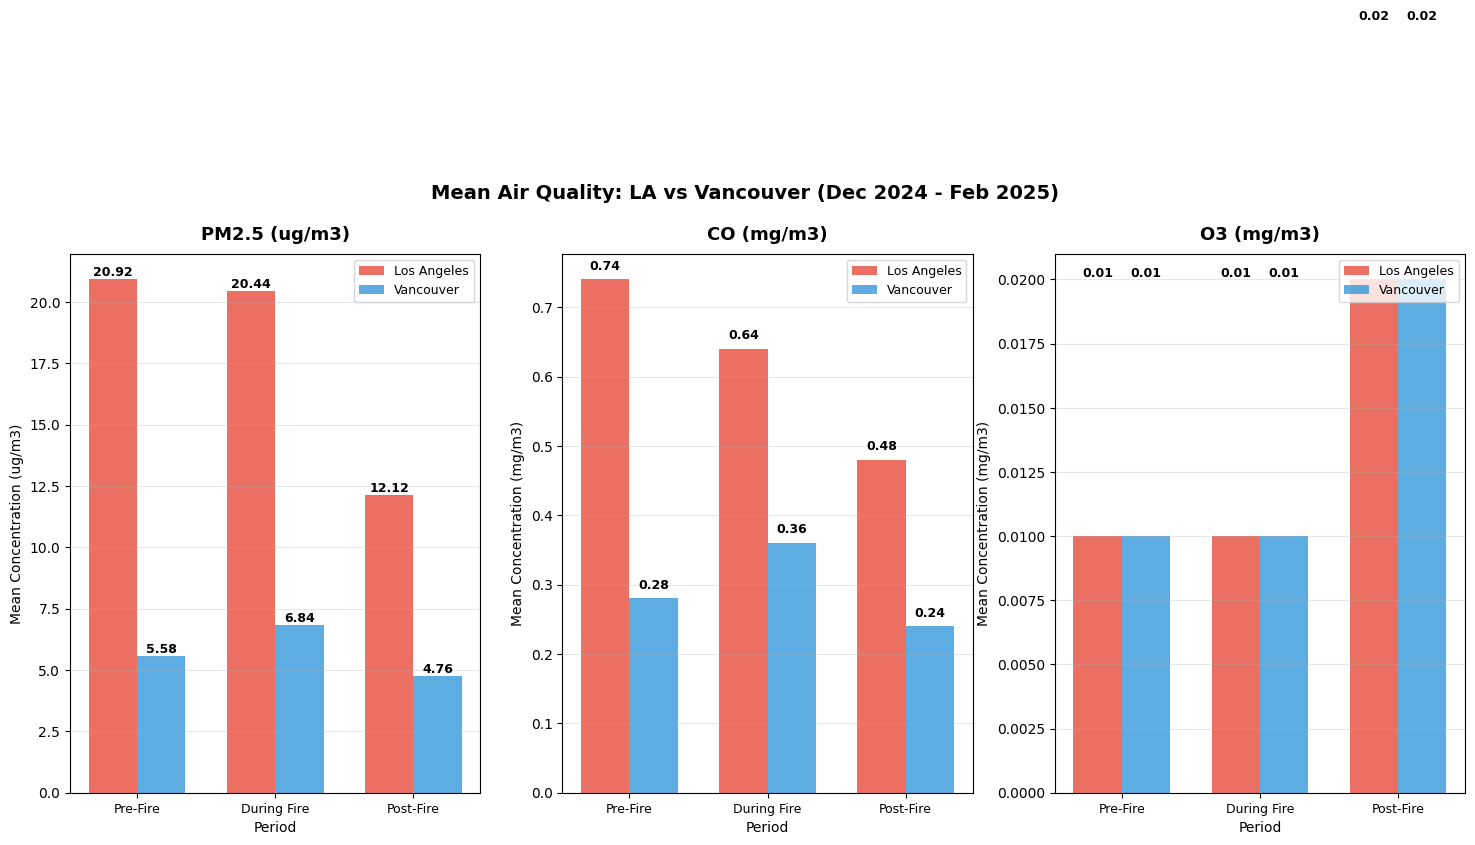

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

parameters_list = ["PM2.5", "CO", "O3"]
period_order = ["Pre-Fire (Dec 2024)", "During Fire (Jan 2025)", "Post-Fire (Feb 2025)"]
period_labels = ["Pre-Fire", "During Fire", "Post-Fire"]
units = {"PM2.5": "ug/m3", "CO": "mg/m3", "O3": "mg/m3"}
colors = {"Los Angeles": "#e74c3c", "Vancouver": "#3498db"}
x = list(range(len(period_order)))
width = 0.35

for i, param in enumerate(parameters_list):
    ax = axes[i]

    for j, (city, color) in enumerate(colors.items()):
        means = []
        for period in period_order:
            val = df_all[(df_all["city"] == city) &
                        (df_all["parameter"] == param) &
                        (df_all["period"] == period)]["value"].mean().round(2)
            means.append(val)

        offset = (j - 0.5) * width
        bars = ax.bar([xi + offset for xi in x], means, width,
                     label=city, color=color, alpha=0.8)

        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f"{mean}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_title(f"{param} ({units[param]})", fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(f"Mean Concentration ({units[param]})", fontsize=10)
    ax.set_xlabel("Period", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(period_labels, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Mean Air Quality: LA vs Vancouver (Dec 2024 - Feb 2025)",
             fontsize=14, fontweight="bold")
fig.subplots_adjust(top=0.88)
plt.savefig("la_vs_vancouver_bar.png", dpi=150, bbox_inches="tight")
plt.show()

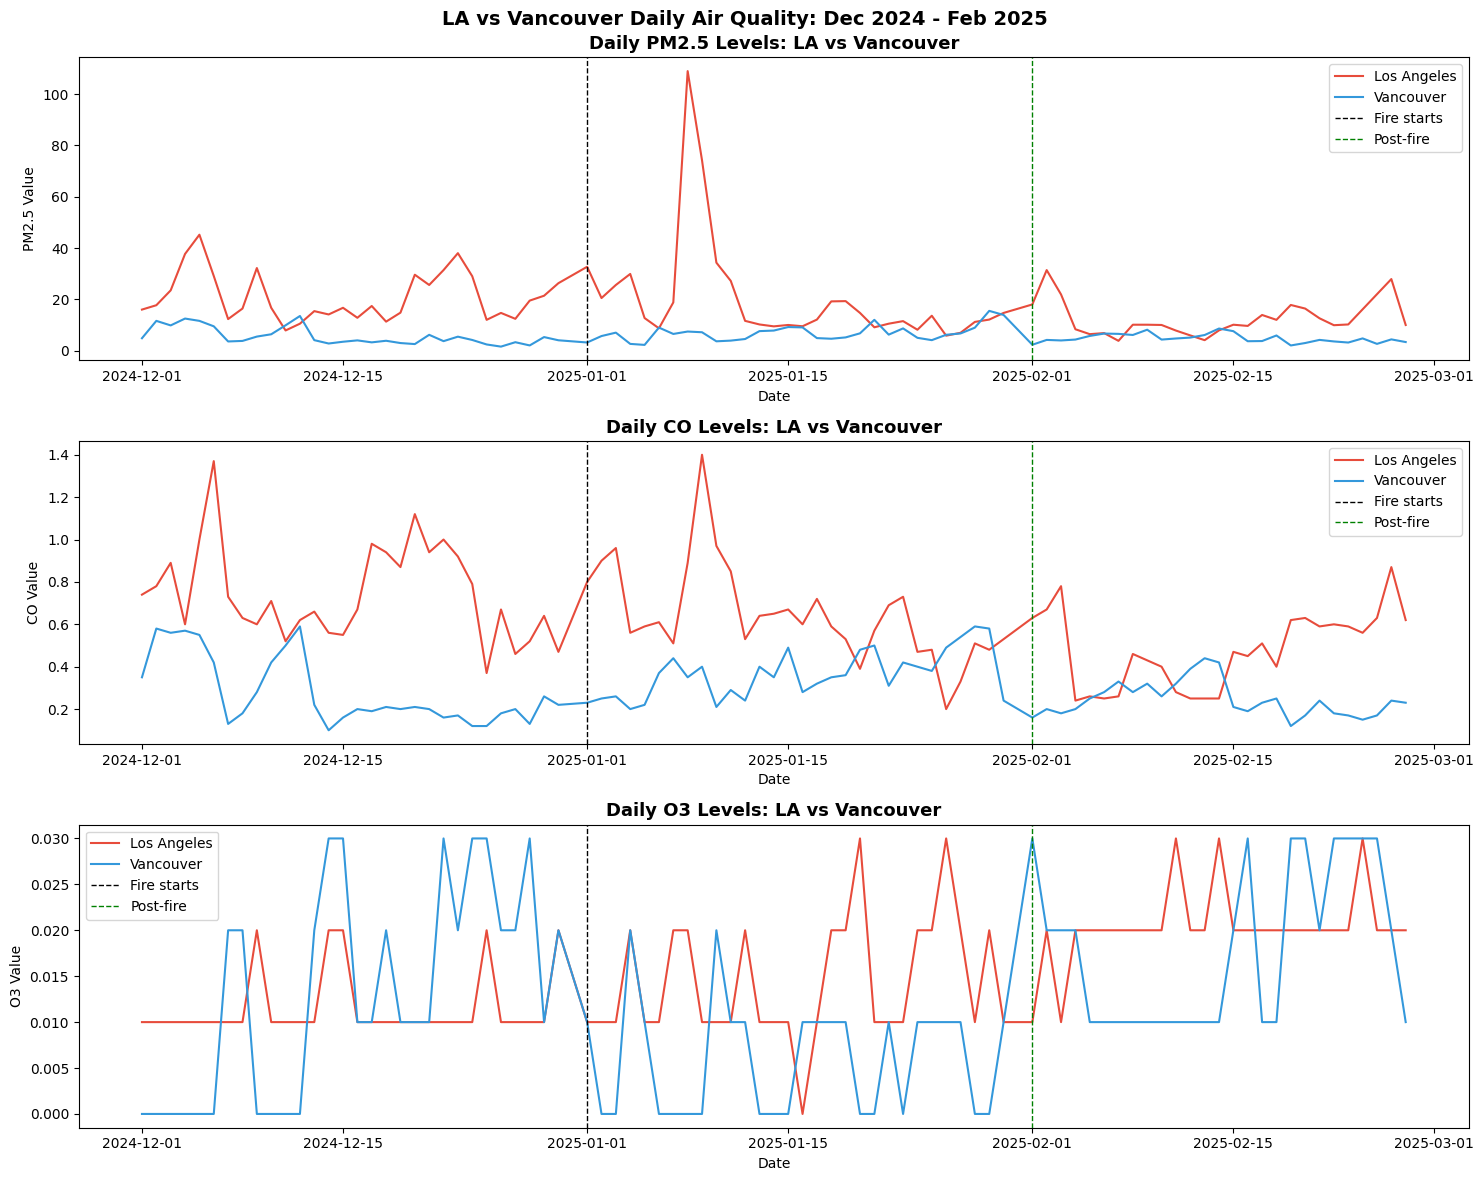

In [7]:
# Daily trend comparison for PM2.5
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

parameters_list = ["PM2.5", "CO", "O3"]
colors = {"Los Angeles": "#e74c3c", "Vancouver": "#3498db"}

for ax, param in zip(axes, parameters_list):
    for city, color in colors.items():
        data = df_all[(df_all["city"] == city) &
                     (df_all["parameter"] == param)].sort_values("date")
        ax.plot(data["date"], data["value"],
               color=color, linewidth=1.5, label=city)

    # Add vertical lines for period boundaries
    ax.axvline(pd.Timestamp("2025-01-01"), color="black",
               linestyle="--", linewidth=1, label="Fire starts")
    ax.axvline(pd.Timestamp("2025-02-01"), color="green",
               linestyle="--", linewidth=1, label="Post-fire")

    ax.set_title(f"Daily {param} Levels: LA vs Vancouver",
                fontsize=13, fontweight="bold")
    ax.set_ylabel(f"{param} Value")
    ax.set_xlabel("Date")
    ax.legend()

plt.suptitle("LA vs Vancouver Daily Air Quality: Dec 2024 - Feb 2025",
            fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("la_vs_vancouver_daily.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Check CO daily values during wildfire period
la_co = df_all[(df_all["city"] == "Los Angeles") &
               (df_all["parameter"] == "CO") &
               (df_all["period"] == "During Fire (Jan 2025)")].sort_values("date")

print("LA Daily CO during wildfire:")
print(la_co[["date", "value"]].to_string())

LA Daily CO during wildfire:
          date  value
115 2025-01-01   0.80
116 2025-01-02   0.90
117 2025-01-03   0.96
118 2025-01-04   0.56
119 2025-01-05   0.59
120 2025-01-06   0.61
121 2025-01-07   0.51
122 2025-01-08   0.89
123 2025-01-09   1.40
124 2025-01-10   0.97
125 2025-01-11   0.85
126 2025-01-12   0.53
127 2025-01-13   0.64
128 2025-01-14   0.65
129 2025-01-15   0.67
130 2025-01-16   0.60
131 2025-01-17   0.72
132 2025-01-18   0.59
133 2025-01-19   0.53
134 2025-01-20   0.39
135 2025-01-21   0.57
136 2025-01-22   0.69
137 2025-01-23   0.73
138 2025-01-24   0.47
139 2025-01-25   0.48
140 2025-01-26   0.20
141 2025-01-27   0.33
142 2025-01-28   0.51
143 2025-01-29   0.48
144 2025-01-30   0.53


In [10]:
# Check CO daily values during wildfire period for both cities
for city in ["Los Angeles", "Vancouver"]:
    print(f"\n--- {city} Daily CO during wildfire ---")
    data = df_all[(df_all["city"] == city) &
                  (df_all["parameter"] == "CO") &
                  (df_all["period"] == "During Fire (Jan 2025)")].sort_values("date")
    print(data[["date", "value"]].to_string())


--- Los Angeles Daily CO during wildfire ---
          date  value
115 2025-01-01   0.80
116 2025-01-02   0.90
117 2025-01-03   0.96
118 2025-01-04   0.56
119 2025-01-05   0.59
120 2025-01-06   0.61
121 2025-01-07   0.51
122 2025-01-08   0.89
123 2025-01-09   1.40
124 2025-01-10   0.97
125 2025-01-11   0.85
126 2025-01-12   0.53
127 2025-01-13   0.64
128 2025-01-14   0.65
129 2025-01-15   0.67
130 2025-01-16   0.60
131 2025-01-17   0.72
132 2025-01-18   0.59
133 2025-01-19   0.53
134 2025-01-20   0.39
135 2025-01-21   0.57
136 2025-01-22   0.69
137 2025-01-23   0.73
138 2025-01-24   0.47
139 2025-01-25   0.48
140 2025-01-26   0.20
141 2025-01-27   0.33
142 2025-01-28   0.51
143 2025-01-29   0.48
144 2025-01-30   0.53

--- Vancouver Daily CO during wildfire ---
          date  value
376 2025-01-01   0.23
377 2025-01-02   0.25
378 2025-01-03   0.26
379 2025-01-04   0.20
380 2025-01-05   0.22
381 2025-01-06   0.37
382 2025-01-07   0.44
383 2025-01-08   0.35
384 2025-01-09   0.40
385 2025

## Conclusion

### Summary of Findings

**PM2.5:**
The most dramatic impact of the wildfires was observed in PM2.5 levels.
Los Angeles experienced a sharp spike reaching 109 ug/m3 in early
January 2025, while Vancouver remained stable between 2-15 ug/m3
throughout the entire period. This confirms that the wildfire was
the primary driver of PM2.5 pollution in LA.

**CO:**
Los Angeles showed consistently higher CO levels than Vancouver,
with a notable spike to 1.4 during the wildfire period. After the
fire, both cities converged toward similar levels, suggesting the
wildfire's direct combustion impact had subsided.

**O3:**
Both cities showed similar O3 patterns throughout all three periods,
suggesting that ground-level ozone was not significantly impacted
by the wildfires in either city.

### Answer to Research Question
The January 2025 wildfires had a clear and measurable impact on
Los Angeles air quality, particularly PM2.5 and CO levels.
Vancouver, unaffected by wildfires, served as an effective control
city, confirming that the pollution spikes observed in LA were
directly caused by the wildfires and not by seasonal or regional
weather patterns.